In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

import scipy.stats as stats
from scipy.stats import ttest_ind

from dotenv import load_dotenv
import os


In [2]:
load_dotenv()



# MySQL connection
username=os.getenv("DB_USERNAME")
password=os.getenv("DB_PASSWORD")
host=os.getenv("DB_HOST")
port=os.getenv("DB_PORT")
database=os.getenv("DB")

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [51]:
df=pd.read_sql("Select * from vendor_sales_summary",engine)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrices,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [52]:
df.shape

(10692, 18)

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrices,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrices           10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  float64
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesDollars      10692 non-null  float64
 11  TotalSalesPrice        10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

In [55]:
numerical_features=df.select_dtypes(include=np.number)

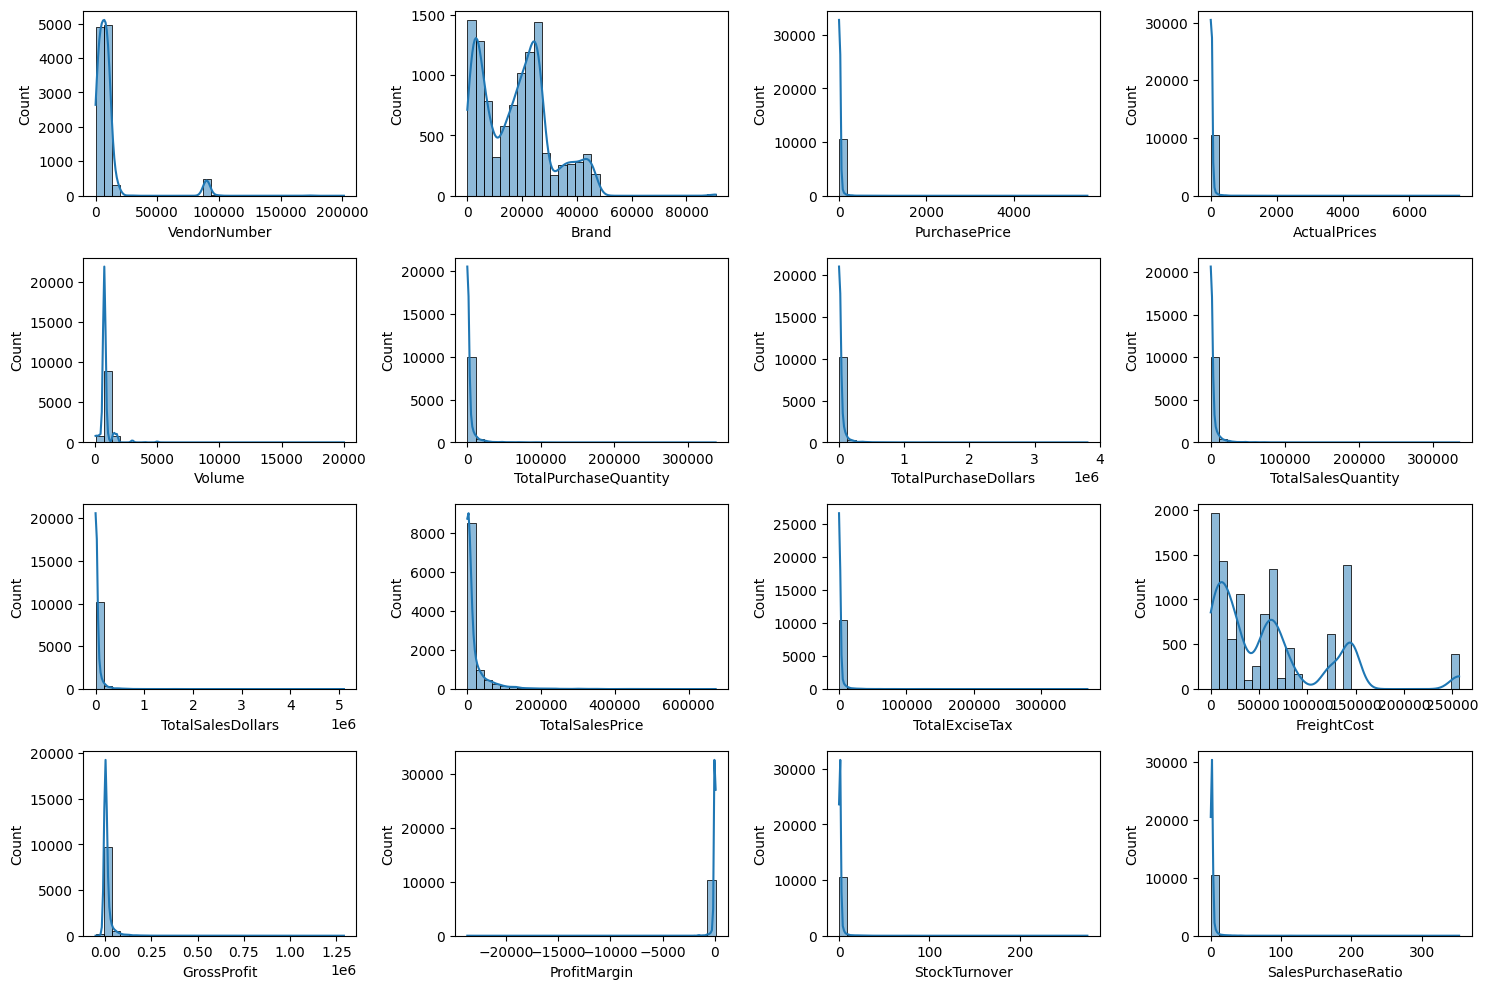

In [56]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    
    

plt.tight_layout()
plt.show()

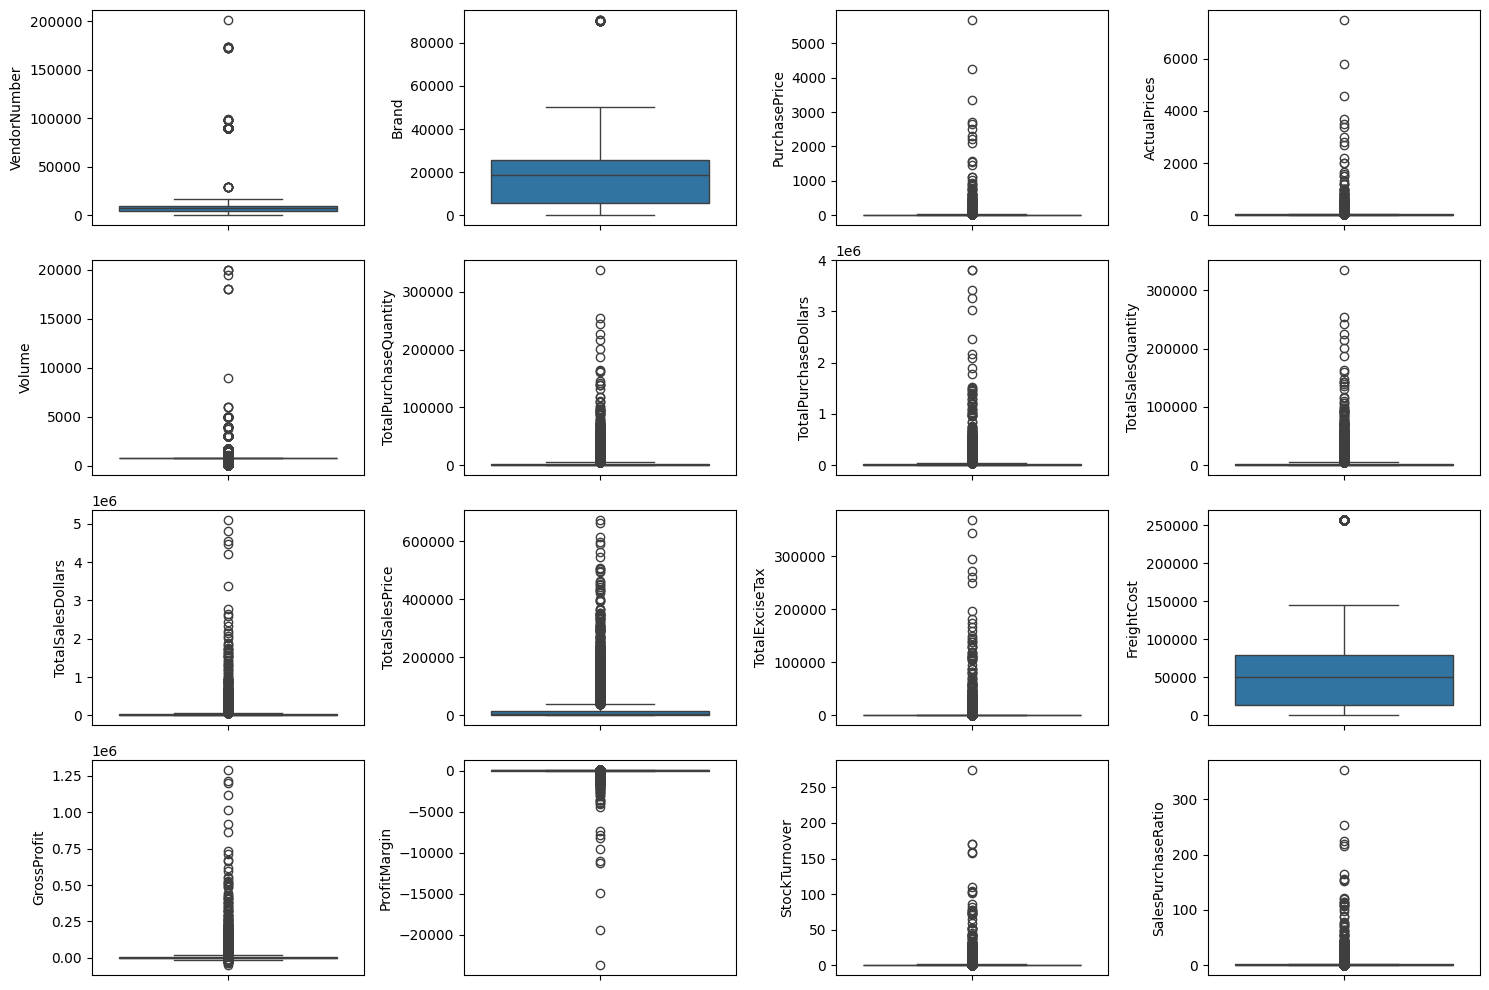

In [57]:

plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_features.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    
    

plt.tight_layout()
plt.show()

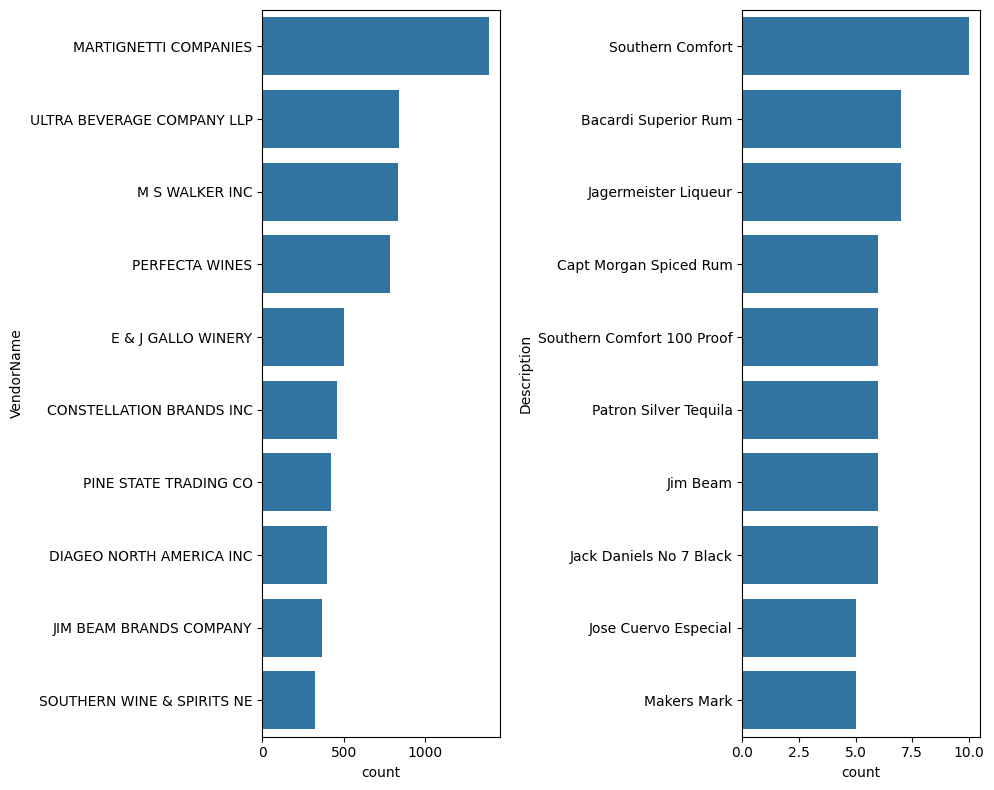

In [58]:
categorical_col=['VendorName','Description']


plt.figure(figsize=(10,8))
for i,col in enumerate(categorical_col):
    plt.subplot(1,2,i+1)
    sns.countplot(df[col],order=df[col].value_counts().index[:10]) #Top 10 category
    
    
plt.tight_layout()
plt.show()

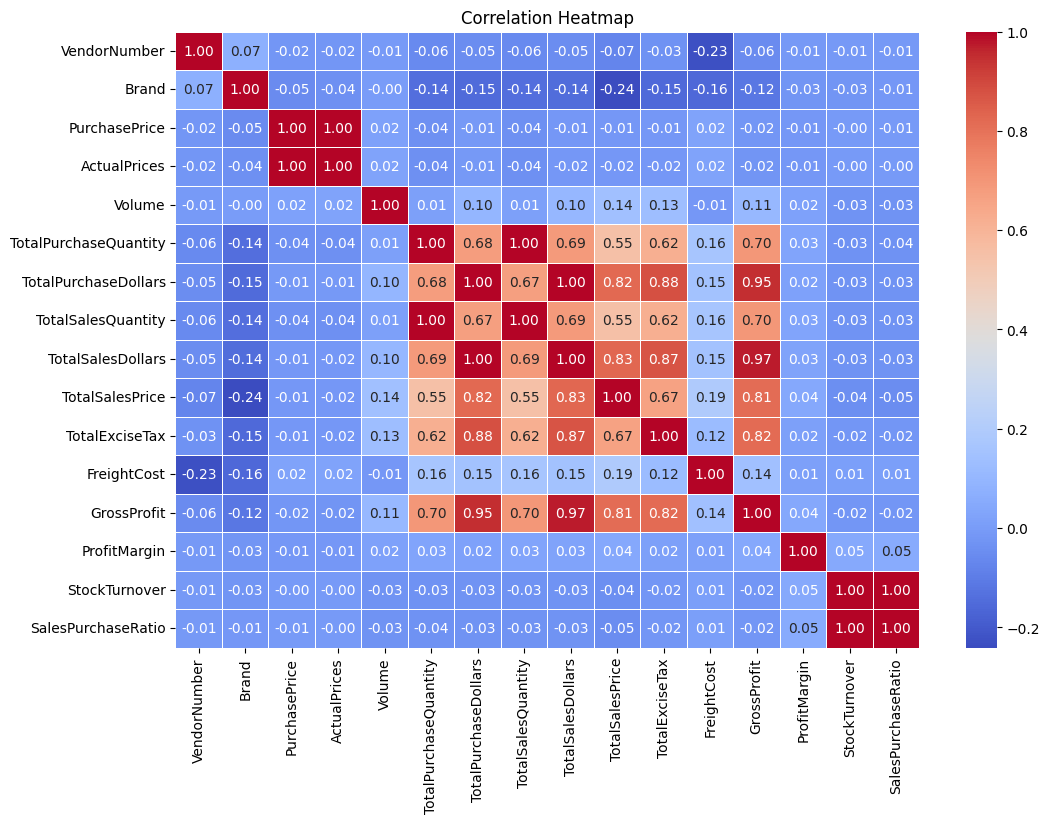

In [59]:
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_features.columns].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Observations

#### Negative & zero values : 

* **Gross Profit** : Minimum value is -52002.78, indicating loss.
* **Profit Margin** : Minimum value is -23730.63, which suggests cases where revenue is zero or even lower than costs.
* **Total sales & sales dollars** : Minimum value is 0, means some products were purchased but never sold.

#### Outliers indicated by high standard deviations : 
* **Purchase & Actual prices** : The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* **Freight Cost** : Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* **Stock Turnover** : Ranges from 0 to 274.5, implying some products sell extremely fast while other remain in stock. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

#### other insights
* PurchasePrice has weak correlations with TotalSalesDollars(-0.012) and GrossProfit(-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between TotalPurchaseQuantity and TotalSalesQuantity(0.999), confirming efficient inventory turnover.
* StockTurnover has weak negative correlations with both GrossProfit(-0.038) and ProfitMargin(-0.055), indicating that faster turnover does not necessarily result in higher profitability.

In [4]:
# filter the data by removing inconsistency
df=pd.read_sql("""select *
               from vendor_sales_summary
               where GrossProfit > 0
               and ProfitMargin >0
               and TotalSalesQuantity > 0""",engine)

## Data Analysis


**Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.**


In [5]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [6]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [7]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [8]:
high_margin_threshold

np.float64(64.97017552750113)

In [9]:
mask1=brand_performance['TotalSalesDollars']<=low_sales_threshold
mask2=brand_performance['ProfitMargin']>=high_margin_threshold

traget_brands=brand_performance[mask1 & mask2]

print("Brands with Low sales but high Profit margins : ")
display(traget_brands.sort_values('TotalSalesDollars'))

Brands with Low sales but high Profit margins : 


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [10]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

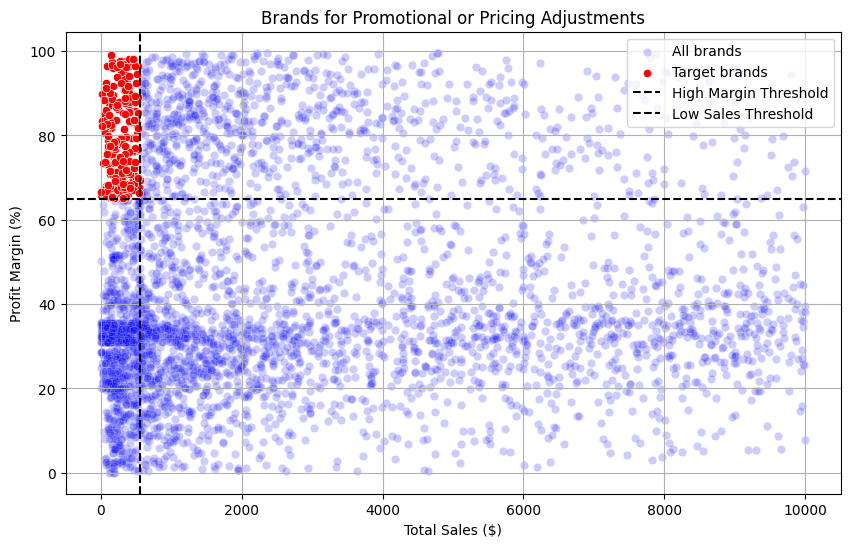

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All brands', alpha=0.2)
sns.scatterplot(data=traget_brands,x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target brands')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label="High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle='--',color='black',label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**Which vendors and brands demonstrate the highest sales performance ?**

In [12]:
top_vendors=df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_product=df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [13]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

In [14]:
top_product.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\283075839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\283075839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')


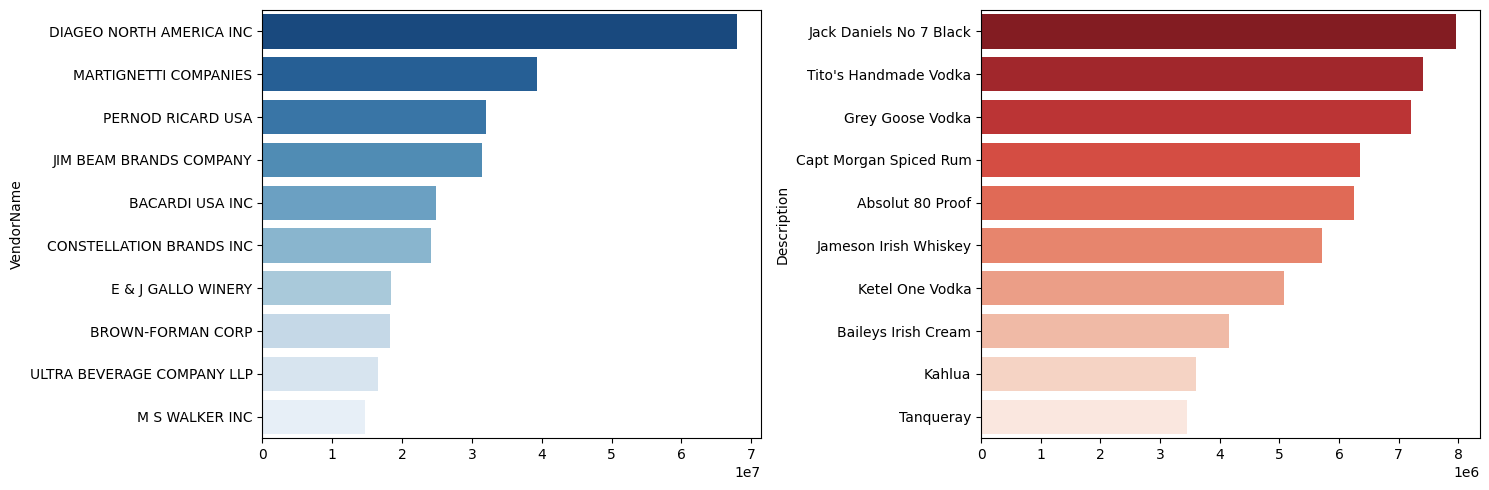

In [15]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")

plt.subplot(1,2,2)
sns.barplot(y=top_product.index,x=top_product.values,palette='Reds_r')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [16]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [17]:
vendor_performance['PurchaseContribution%']=(vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum())*100

In [18]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [19]:
top_vendors=vendor_performance.head(10)

In [20]:
#display top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\2018632613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\2018632613.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\2018632613.py:5: SettingWit

In [21]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [22]:
top_vendors["PurchaseContribution%"].sum()

np.float64(65.69000000000001)

* top 10 vendors has 65% contribution in purchase

In [23]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\2851312941.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()


In [24]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\3518096017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\3518096017.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)


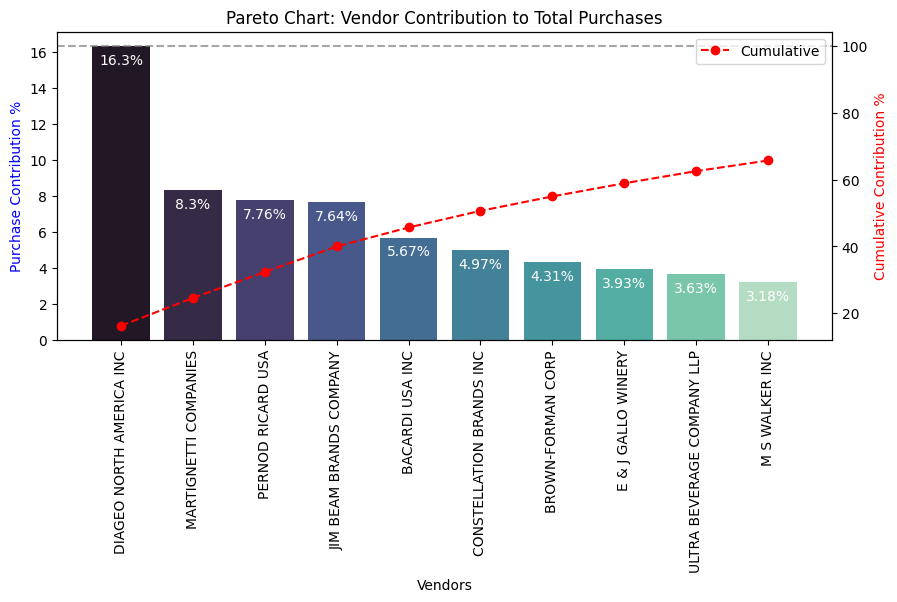

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 4))

# Bar plot for Purchase Contribution
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],                 # x (positional)
    top_vendors['Cumulative_Contribution%'],    # y (positional)
    color='red', marker='o', linestyle='dashed', label='Cumulative'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

**How much of total procurement is dependent on the top vendors?**

In [26]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


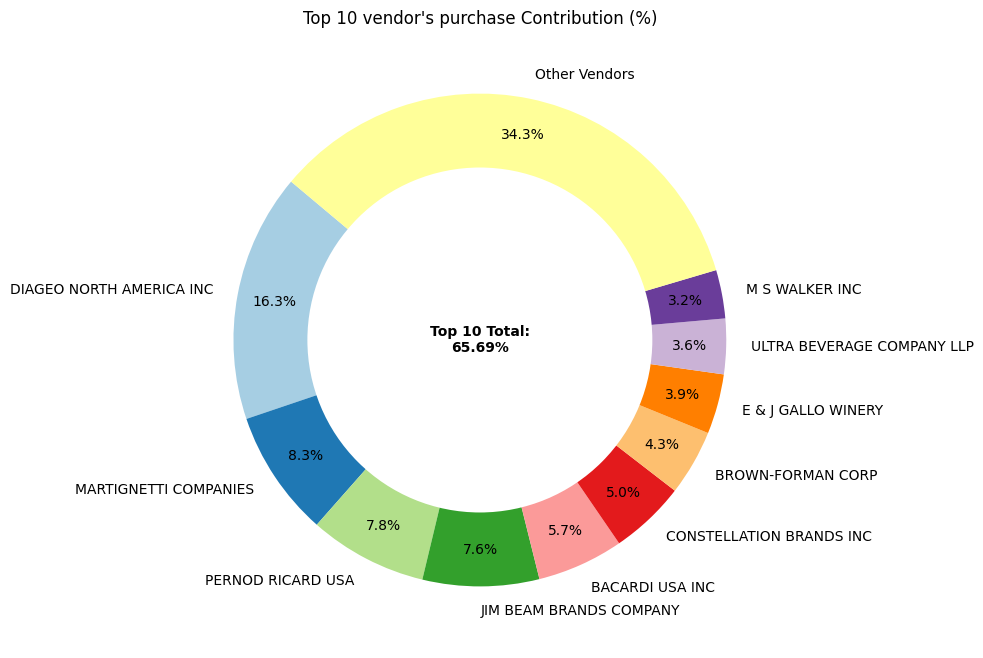

In [27]:
vendors=list(top_vendors['VendorName'].values)
purchase_contributions=list(top_vendors['PurchaseContribution%'].values)

total_contribution=sum(purchase_contributions)
remaining_contribution=100-total_contribution

# Append "other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)


# Donut chart
fig, ax= plt.subplots(figsize=(8,8))
wedges, texts,autotexts =ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Add total contribution annotation in the center
plt.text(0,0,f"Top 10 Total:\n{total_contribution:.2f}%",fontsize=10,fontweight='bold',ha='center',va='center')

plt.title("Top 10 vendor's purchase Contribution (%)")
plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving?**

In [28]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [29]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['Small','Medium','Large'])

In [30]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\1505448859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


C:\Users\Ashish Panchal\AppData\Local\Temp\ipykernel_17308\567960540.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')


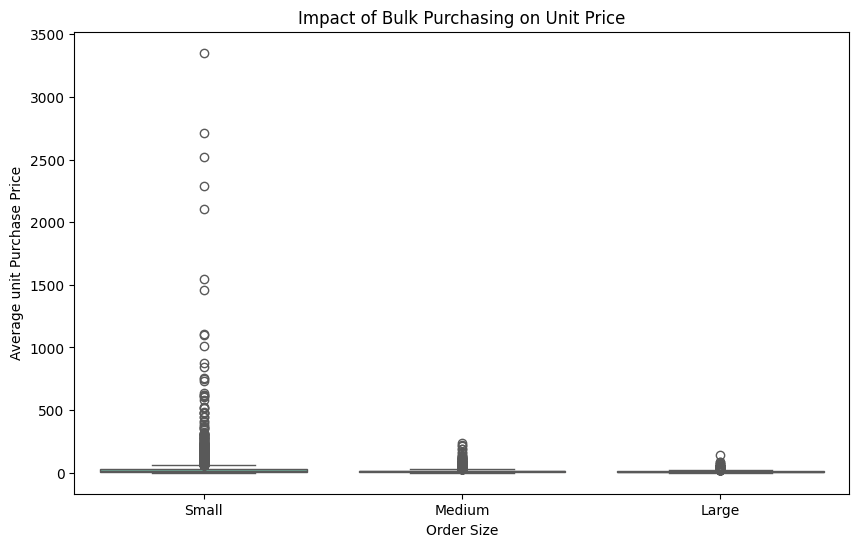

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average unit Purchase Price")
plt.show()

* Vendors buying in bulk get the lowest unit price, means higher margin if they can manage inventory efficiently.
* This suggest that bulk pricing strategies successfully encourage vendors to pruchase in larger volumes, leading to higher overall sales.


**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [32]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it ?**

In [33]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
format_dollars(df['UnsoldInventoryValue'].sum())

'2.71M'

In [34]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with the highest locked capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)


In [35]:
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?**

In [36]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)


In [37]:
top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

In [38]:
low_vendors

6450     0.327788
6456     0.644476
6496     1.672267
6506     9.984425
6513     9.473185
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 1280, dtype: float64

In [39]:
def confidence_interval(data,confidence=0.95):
    mean_value=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data)) # standard error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_value,mean_value-margin_of_error,mean_value+margin_of_error


Top Vendors 95% CI : (30.74, 31.61), Mean : 31.18
Low Vendors 95% CI : (37.22, 39.75), Mean : 38.49


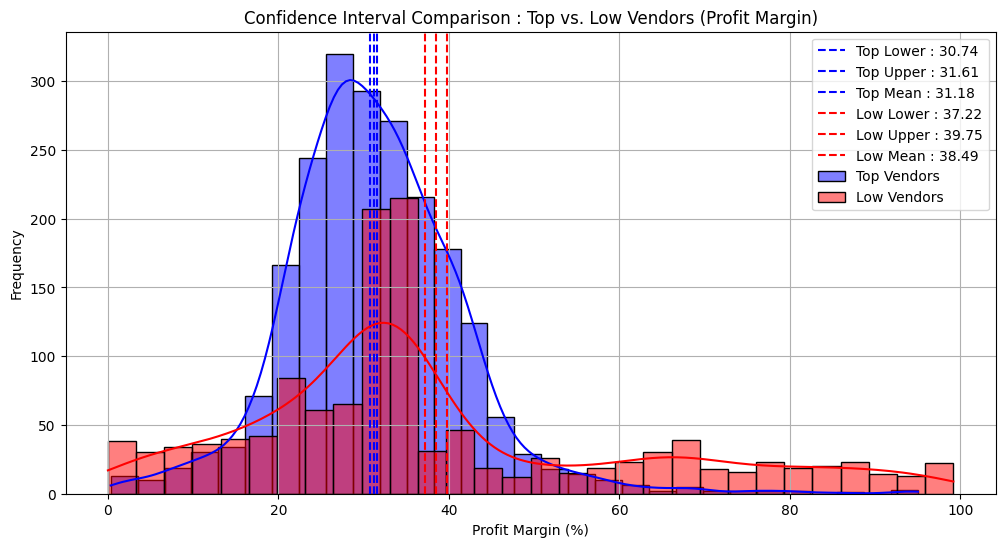

In [40]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)

print(f"Top Vendors 95% CI : ({top_lower:.2f}, {top_upper:.2f}), Mean : {top_mean:.2f}")
print(f"Low Vendors 95% CI : ({low_lower:.2f}, {low_upper:.2f}), Mean : {low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top Vendors plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label="Top Vendors")
plt.axvline(top_lower,color='blue',linestyle="--",label=f"Top Lower : {top_lower:.2f}")
plt.axvline(top_upper,color='blue',linestyle="--",label=f"Top Upper : {top_upper:.2f}")
plt.axvline(top_mean,color="blue",linestyle="--",label=f"Top Mean : {top_mean:.2f}")



# Low Vendors plot

sns.histplot(low_vendors,kde=True,color="red",bins=30,alpha=0.5,label="Low Vendors")
plt.axvline(low_lower,color='red',linestyle="--",label=f"Low Lower : {low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle="--",label=f"Low Upper : {low_upper:.2f}")
plt.axvline(low_mean,color="red",linestyle="--",label=f"Low Mean : {low_mean:.2f}")


# Finalize plot
plt.title("Confidence Interval Comparison : Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

#### Hypothesis Testing

Is there a significant difference in profit margins between top-performing and low-performing vendors?



**Null Hypothesis** : There is no significant difference in the mean profit margin of top-performing and low-performing vendors.

**Alternative Hypothesis**  : The mean profit margins of top-performing and low-performing vendors are significantly different.

In [41]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

top_vendors=df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars'] <= low_sales_threshold]['ProfitMargin'].dropna()

# Perform two sample t-test
t_stat,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)

#Result
print(f"T-Statistic : {t_stat:.4f}, P-Value : {p_value:.4f}")
if p_value<0.05:
    print("Reject Null Hypothesis")
    print("There is significant difference in profit margin between top and low performing vendors.")
else:
    print("Fail to reject Null Hypothesis : No significant difference in profit margins.")


T-Statistic : -10.7137, P-Value : 0.0000
Reject Null Hypothesis
There is significant difference in profit margin between top and low performing vendors.


In [44]:
df.to_sql(
    name="vendor_sales_summary",   
    con=engine,
    if_exists="replace",           # 'replace' = drop & recreate, 'append' = add rows, 'fail' = error if exist
    index=False                  
)

8564